In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
def softmax(z):
    """
    Compute the softmax probabilities for a given input matrix.
    Uses numerical stabilization by subtracting the max value per row.
    """
    # Subtract max per row for numerical stability [cite: 111]
    z_stable = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_stable)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

# Test Case [cite: 122-127]
z_test = np.array([[2.0, 1.0, 0.1], [1.0, 1.0, 1.0]])
softmax_output = softmax(z_test)
assert np.allclose(np.sum(softmax_output, axis=1), 1)
print("Softmax function passed the test case!")

Softmax function passed the test case!


In [3]:
def predict_softmax(X, W, b):
    """
    Predict class labels using the trained softmax model[cite: 131].
    """
    # Compute logits [cite: 110]
    z = np.dot(X, W) + b
    probabilities = softmax(z)
    # Select the index of the highest probability [cite: 67]
    return np.argmax(probabilities, axis=1)

In [21]:
def cost_softmax(X, y, W, b):
    """
    Compute the average cross-entropy loss over all samples[cite: 253].
    """
    n = X.shape[0]
    z = np.dot(X, W) + b
    y_pred = softmax(z)

    # Categorical Cross-Entropy with numerical stability
    # Adding 1e-12 prevents log(0) which causes "nan" issues
    total_loss = -np.sum(y * np.log(y_pred + 1e-12))

    return total_loss / n # [cite: 266]

In [22]:
def compute_gradient_softmax(X, y, W, b):
    """
    Compute gradients with respect to weights and biases[cite: 354].
    """
    n = X.shape[0]
    z = np.dot(X, W) + b
    y_pred = softmax(z)
    error = y_pred - y  # Difference between prediction and true labels

    # Matrix multiplication for gradients
    grad_W = np.dot(X.T, error) / n
    grad_b = np.sum(error, axis=0) / n

    return grad_W, grad_b

In [23]:
def gradient_descent_softmax(X, y, W, b, alpha, n_iter, show_cost=False):
    """
    Optimize weights and biases using Gradient Descent[cite: 390].
    """
    cost_history = []
    for i in range(n_iter):
        grad_W, grad_b = compute_gradient_softmax(X, y, W, b)

        # Parameter Update Rule [cite: 340]
        W -= alpha * grad_W
        b -= alpha * grad_b

        current_cost = cost_softmax(X, y, W, b)
        cost_history.append(current_cost)

        if show_cost and i % 100 == 0:
            print(f"Iteration {i}: Cost = {current_cost:.4f}")

    return W, b, cost_history

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

def plot_sample_images(X, y):
    """
    Plots one sample image for each digit class (0-9).
    """
    plt.figure(figsize=(10, 4))
    unique_classes = np.unique(y) # Get unique class labels

    for i, digit in enumerate(unique_classes):
        index = np.where(y == digit)[0][0] # Find first occurrence of the class
        image = X[index].reshape(28, 28) # Reshape 1D array to 28x28

        plt.subplot(2, 5, i + 1)
        plt.imshow(image, cmap='gray')
        plt.title(f"Digit: {digit}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

def load_and_prepare_mnist(csv_file, test_size=0.2, random_state=42):
    """
    Reads the MNIST CSV file, splits data into train/test sets, and plots one image per class.
    """
    # Load dataset
    df = pd.read_csv(csv_file)

    # Separate labels and features
    y = df.iloc[:, 0].values # First column is the label
    X = df.iloc[:, 1:].values # Remaining columns are pixel values

    # Normalize pixel values to scale between 0 and 1
    X = X / 255.0

    # Plot one sample image per class for visualization
    plot_sample_images(X, y)

    # Split data into training and test sets
    return train_test_split(X, y, test_size=test_size, random_state=random_state)

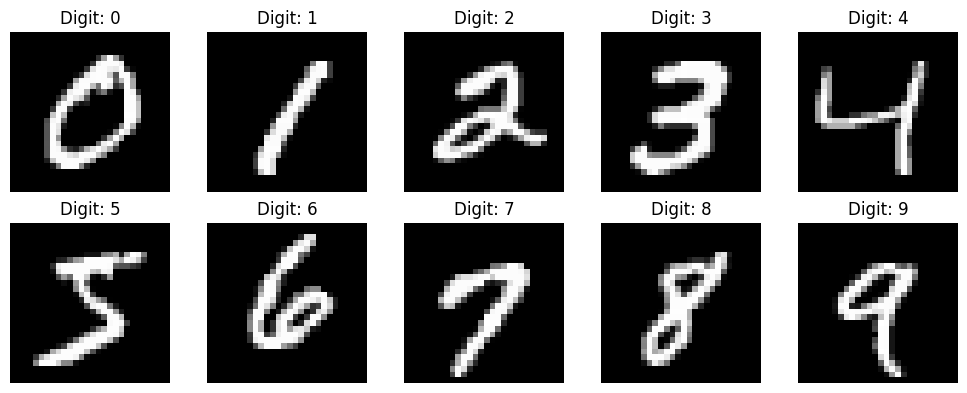

In [25]:
# 1. Specify your filename (ensure this file is uploaded to Colab)
csv_file_path = "mnist_dataset.csv"

# 2. Call the function to load, normalize, and plot
X_train, X_test, y_train, y_test = load_and_prepare_mnist(csv_file_path)

In [26]:
from sklearn.preprocessing import OneHotEncoder

# 1. One-hot encode the training and test labels
encoder = OneHotEncoder(sparse_output=False)
y_train_oh = encoder.fit_transform(y_train.reshape(-1, 1))
y_test_oh = encoder.transform(y_test.reshape(-1, 1))

# 2. Verify dimensions before training [cite: 490-492]
assert len(X_train) == len(y_train_oh), "Error: X and y lengths do not match!"
print(f"Move forward: Feature matrix and label vector matched. (Samples: {len(X_train)})")

# 3. Initialize hyperparameters [cite: 513-514]
alpha = 0.1      # Learning rate
n_iter = 1000    # Number of iterations

# 4. Initialize parameters with zeros or small random values [cite: 507-511]
d = X_train.shape[1] # Number of features (784 pixels)
c = 10               # Number of classes (0-9)
W = np.zeros((d, c))
b = np.zeros(c)

print("Labels one-hot encoded and parameters initialized.")

Move forward: Feature matrix and label vector matched. (Samples: 48000)
Labels one-hot encoded and parameters initialized.


Iteration 0: Cost = 2.1967
Iteration 100: Cost = 0.6070
Iteration 200: Cost = 0.4894
Iteration 300: Cost = 0.4408
Iteration 400: Cost = 0.4128
Iteration 500: Cost = 0.3939
Iteration 600: Cost = 0.3801
Iteration 700: Cost = 0.3694
Iteration 800: Cost = 0.3608
Iteration 900: Cost = 0.3536


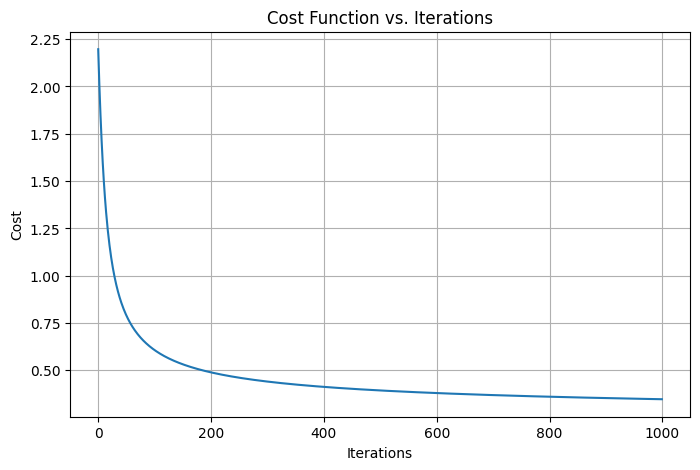

In [27]:
# Train the model
W_opt, b_opt, cost_history = gradient_descent_softmax(
    X_train, y_train_oh, W, b, alpha, n_iter, show_cost=True
)

# Plot the cost history to visualize convergence [cite: 496, 518-524, 540]
plt.figure(figsize=(8, 5))
plt.plot(cost_history)
plt.title('Cost Function vs. Iterations')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.grid(True)
plt.show()

In [28]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

def evaluate_classification(y_true, y_pred):
    """
    Evaluate classification performance using confusion matrix, precision, recall, and F1-score.
    """
    # Compute confusion matrix [cite: 558-560]
    cm = confusion_matrix(y_true, y_pred)

    # Compute precision, recall, and F1-score using weighted average [cite: 561-565]
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    return cm, precision, recall, f1

# 1. Predict on the test set [cite: 570]
y_pred_test = predict_softmax(X_test, W_opt, b_opt)

# 2. Convert one-hot test labels back to numeric labels (0-9)
y_test_labels = np.argmax(y_test_oh, axis=1)

# 3. Evaluate the model [cite: 574-575]
cm, precision, recall, f1 = evaluate_classification(y_test_labels, y_pred_test)

# 4. Print results [cite: 576-581]
print("\nEvaluation Metrics:")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")


Evaluation Metrics:
Precision: 0.90
Recall: 0.90
F1-Score: 0.90


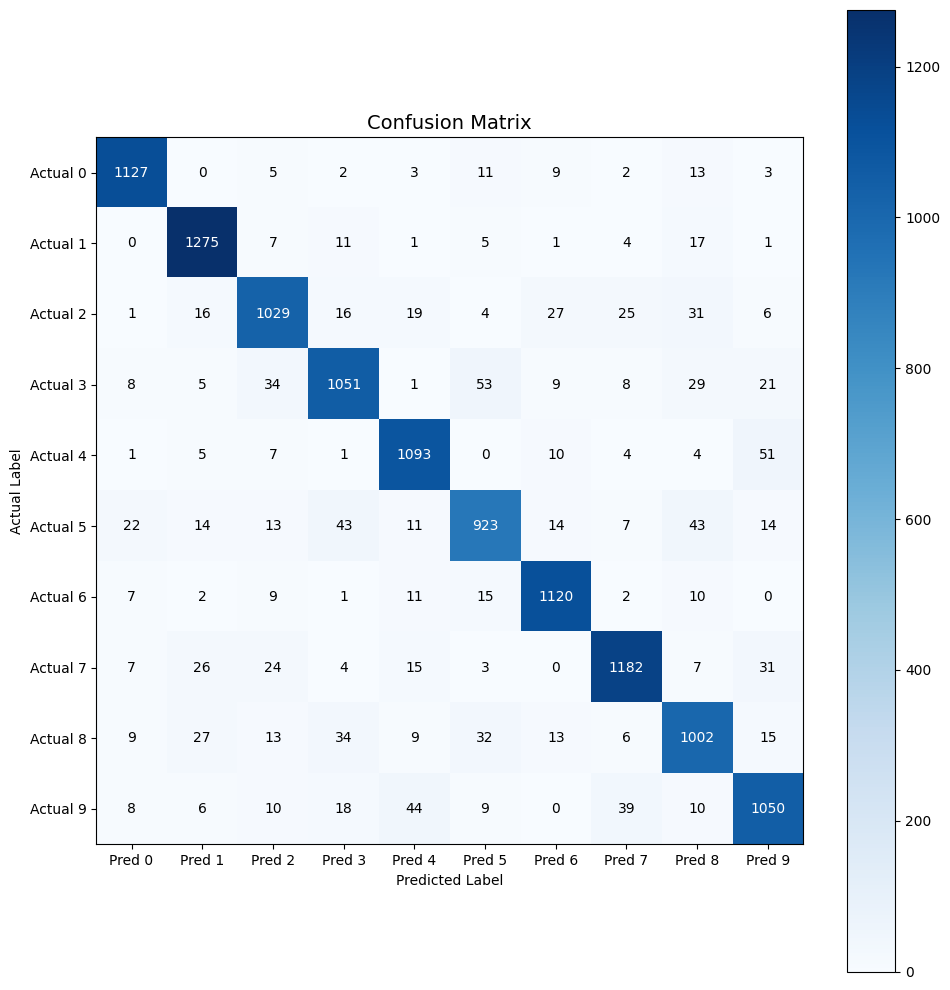

In [29]:
# Create visualization [cite: 583-584]
fig, ax = plt.subplots(figsize=(10, 10))
cax = ax.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix', fontsize=14)
plt.colorbar(cax)

# Set axis labels [cite: 587-590, 600]
num_classes = cm.shape[0]
ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels([f'Pred {i}' for i in range(num_classes)])
ax.set_yticklabels([f'Actual {i}' for i in range(num_classes)])

# Add value labels to each cell [cite: 591-594]
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > np.max(cm)/2 else 'black')

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()

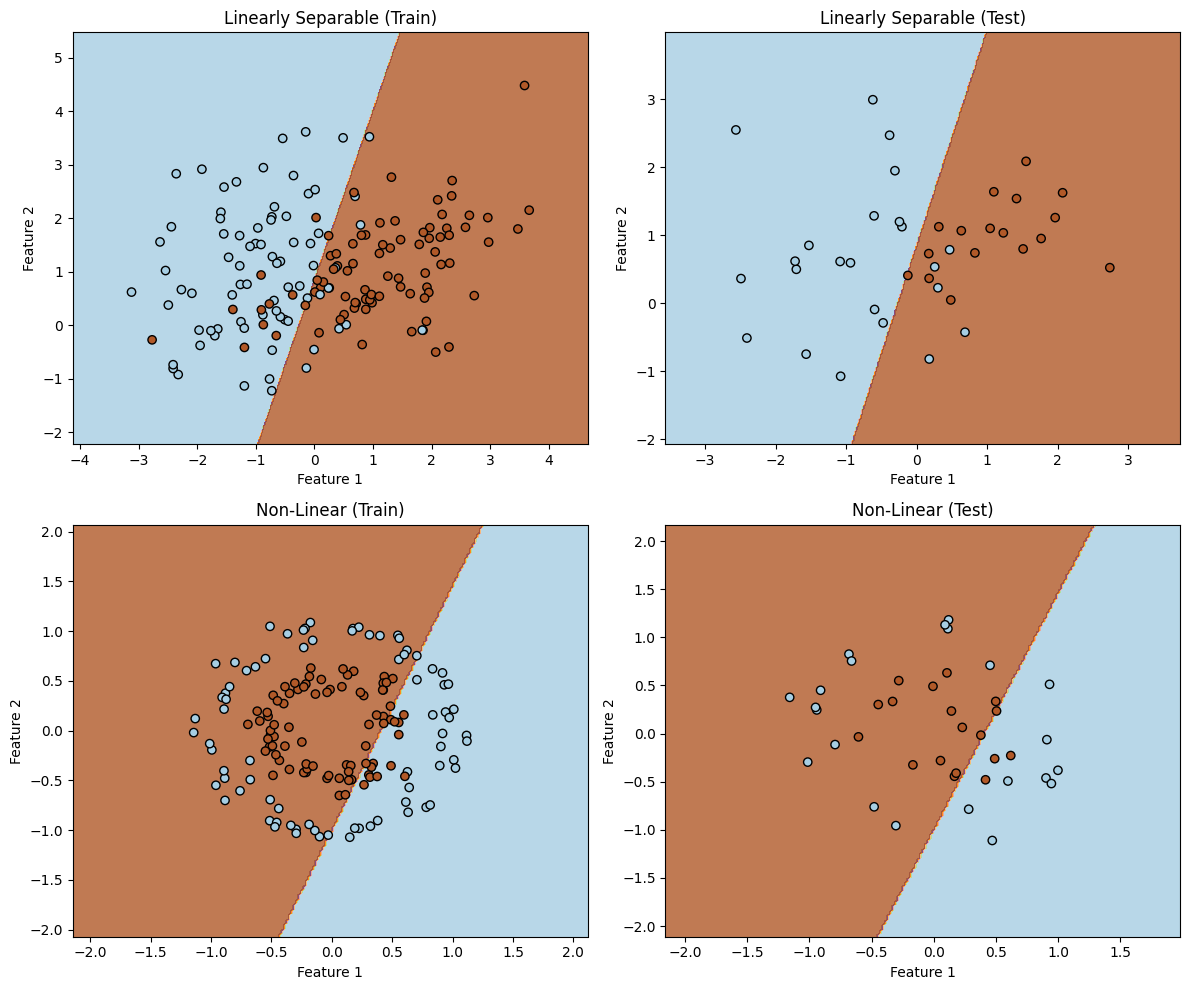

In [30]:
from sklearn.datasets import make_classification, make_circles
from sklearn.linear_model import LogisticRegression

# 1. Setup and Data Generation
np.random.seed(42)

# Linearly Separable Data
X_lin, y_lin = make_classification(n_samples=200, n_features=2, n_informative=2,
                                   n_redundant=0, n_clusters_per_class=1, random_state=42)
X_train_lin, X_test_lin, y_train_lin, y_test_lin = train_test_split(X_lin, y_lin, test_size=0.2, random_state=42)

# Non-Linearly Separable Data (Circles)
X_circle, y_circle = make_circles(n_samples=200, noise=0.1, factor=0.5, random_state=42)
X_train_circle, X_test_circle, y_train_circle, y_test_circle = train_test_split(X_circle, y_circle, test_size=0.2, random_state=42)

# 2. Train Models
model_lin = LogisticRegression().fit(X_train_lin, y_train_lin)
model_circle = LogisticRegression().fit(X_train_circle, y_train_circle)

# 3. Plotting Function
def plot_decision_boundary(ax, model, X, y, title):
    h = .02 # Step size in mesh
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.Paired)
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.Paired)
    ax.set_title(title)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

# 4. Create Visualization
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
plot_decision_boundary(axes[0, 0], model_lin, X_train_lin, y_train_lin, 'Linearly Separable (Train)')
plot_decision_boundary(axes[0, 1], model_lin, X_test_lin, y_test_lin, 'Linearly Separable (Test)')
plot_decision_boundary(axes[1, 0], model_circle, X_train_circle, y_train_circle, 'Non-Linear (Train)')
plot_decision_boundary(axes[1, 1], model_circle, X_test_circle, y_test_circle, 'Non-Linear (Test)')

plt.tight_layout()
plt.savefig('decision_boundaries.png')
plt.show()